# VQ-VAE MNIST

In this notebook we train a Vector Quantized Variational Auto-Encoder (VQ-VAE), proposed by [van den Oord et al. 2017](https://arxiv.org/abs/1711.00937).

A standard [VAE](vae_mnist.ipynb) encodes an image into a continuous Gaussian latent. The VQ-VAE instead snaps the encoder output to the nearest entry of a learned codebook, so the latent representation of an image is a small grid of discrete integer indices rather than a vector of reals.

This changes what the trained model can do. A VAE can generate by drawing its latent from the prior $\mathcal{N}(0, I)$, since that prior is part of the model by construction. A VQ-VAE has no corresponding distribution over index grids, so a trained VQ-VAE can reconstruct but not generate. Generation requires a second model, trained afterwards, that learns the distribution over index grids.

The result is the two-stage structure the paper describes, which corresponds to two classes in `lightning_uq_box`:

| Stage | Class | Trains | Gives you |
| --- | --- | --- | --- |
| 1 | `VQVAE` | encoder + codebook + decoder | reconstruction, a discrete index grid |
| 2 | `VQVAEPrior` | a `PixelCNN` over the index grid (VQ-VAE frozen) | generation, by ancestral sampling |

We train both stages below and finish by sampling digits from the prior.

In [1]:
%%capture
%pip install git+https://github.com/lightning-uq-box/lightning-uq-box.git

## Imports

In [2]:
import os
import tempfile
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from lightning import LightningDataModule, Trainer
from lightning.pytorch import seed_everything
from lightning.pytorch.loggers import CSVLogger
from segmentation_models_pytorch.encoders import TimmUniversalEncoder
from torch import Tensor
from torchvision.utils import make_grid

from lightning_uq_box.uq_methods import VQVAE, VQVAELoss, VQVAEPrior
from lightning_uq_box.viz_utils import plot_training_metrics

plt.rcParams["figure.figsize"] = [14, 5]

%load_ext autoreload
%autoreload 2

In [3]:
seed_everything(0)

0

In [4]:
my_temp_dir = tempfile.mkdtemp()

## Datamodule

The following sets up MNIST resized to 32x32 and normalized to $[-1, 1]$, the range the decoder outputs. As with the VAE, the target is the input itself, since the task is reconstruction.

In [5]:
def collate_fn(batch):
    """Collate function for dataloader as dictionary."""
    images, targets = zip(*batch)
    images = torch.stack(images)
    targets = torch.tensor(targets)
    # the target is also the image, since we want to reconstruct it
    return {"input": images, "target": images, "labels": targets}


class MNISTDatamodule(LightningDataModule):
    def __init__(
        self, root: str, batch_size: int = 64, num_workers: int = 0, resize: int = 32
    ):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.root = root
        self.resize = resize

    def _transform(self):
        return torchvision.transforms.Compose(
            [
                torchvision.transforms.ToTensor(),
                torchvision.transforms.Resize((self.resize, self.resize)),
                # normalize to [-1, 1], the range the decoder outputs
                torchvision.transforms.Normalize((0.5,), (0.5,)),
            ]
        )

    def setup(self, stage: str) -> None:
        """Set up the datasets."""
        if stage in ["fit", "validate"]:
            mnist_train = torchvision.datasets.MNIST(
                self.root, train=True, download=True, transform=self._transform()
            )
            self.mnist_train, self.mnist_val = torch.utils.data.random_split(
                mnist_train, [55000, 5000]
            )
        if stage in ["test"]:
            self.mnist_test = torchvision.datasets.MNIST(
                self.root, train=False, download=True, transform=self._transform()
            )

    def train_dataloader(self):
        return torch.utils.data.DataLoader(
            self.mnist_train,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=collate_fn,
        )

    def val_dataloader(self):
        return torch.utils.data.DataLoader(
            self.mnist_val,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            collate_fn=collate_fn,
        )

    def test_dataloader(self):
        return torch.utils.data.DataLoader(
            self.mnist_test,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            collate_fn=collate_fn,
        )

## Stage 1: the VQ-VAE

### Geometry

The encoder determines the size of the latent index grid, which in turn sets the cost of stage 2, so it is worth checking before training anything.

The grid is `img_size // encoder.output_stride`. A `resnet18` at `depth=2` has `output_stride=4`, so a 32x32 input gives an 8x8 grid, or 64 discrete indices per image. This is the geometry the paper uses for CIFAR-10.

Stage 2 needs one sequential forward pass per grid position, so an 8x8 grid costs 64 passes per sample, while a 16x16 grid would cost 256. Let us confirm the grid size we get from this encoder.

In [6]:
encoder = TimmUniversalEncoder("resnet18", depth=2, in_channels=1)
feature = encoder(torch.randn(1, 1, 32, 32))[-1]
print(f"encoder output_stride: {encoder.output_stride}")
print(f"last feature map:      {tuple(feature.shape)}")
print(
    f"latent grid:           {32 // encoder.output_stride}x{32 // encoder.output_stride}"
)

encoder output_stride: 4
last feature map:      (1, 64, 8, 8)
latent grid:           8x8


### The model

Two arguments are specific to vector quantization:

- `codebook_size` sets how many discrete codes are available, 512 in the paper. This is the vocabulary size that stage 2 will model.
- `sample_codebook_temp` sets the temperature for the stochastic codebook sampling used at prediction time, which is what lets `predict_step` return an uncertainty. With `num_samples > 1`, each draw perturbs the code assignment, and the spread across draws is returned as `pred_uct`. At `0.0` every draw would be the same deterministic nearest-neighbour lookup, so `VQVAE` raises a `ValueError` if you combine it with `num_samples > 1` rather than returning an identically zero uncertainty.

This stochastic sampling is confined to `predict_step`. During training the encoder output is always snapped to its nearest code, as the paper specifies, for reasons covered in the note on `stochastic_sample_codes` below.

Four further arguments control codebook health. The library defaults are `decay=0.8`, `kmeans_init=False` and `threshold_ema_dead_code=0`, so the values set here differ from what you get by constructing a `VectorQuantize` yourself:

- `decay` (0.99) is the EMA decay for the codebook update, following the paper and common reference implementations.
- `kmeans_init` (True) initializes the codebook from k-means centroids of the first batch, so codes start in the region the data occupies rather than wherever random initialization places them.
- `threshold_ema_dead_code` (2) resamples codes whose EMA cluster size falls below this value from the current batch. This is the standard dead-code revival mechanism, and `0` disables it.
- `rotation_trick` (True) selects how gradients propagate through the non-differentiable quantization step. The note below covers why this one is worth setting explicitly.

`VQVAELoss` has one parameter, the commitment cost $\beta$, which weights how strongly the encoder is pushed toward the code it selected. The paper uses 0.25 and reports that results are robust between 0.1 and 2.0.

In [7]:
vqvae = VQVAE(
    encoder=TimmUniversalEncoder("resnet18", depth=2, in_channels=1),
    out_channels=1,  # MNIST is single channel
    img_size=32,
    codebook_size=512,
    sample_codebook_temp=1.0,  # > 0 so that predict_step gives non-zero uncertainty
    num_samples=5,
    loss_fn=VQVAELoss(commit_scale=0.25),  # beta = 0.25, the paper's value
    optimizer=partial(torch.optim.Adam, lr=3e-4),
)

> **Two settings that a forward-pass test cannot check**
>
> We ran into both of these while reproducing the paper's CIFAR-10 experiment. Both produce plausible-looking training curves when set wrongly.
>
> **1. `stochastic_sample_codes` should stay off during training.** The library flag gates on `module.training`, so enabling it makes training assign codes by sampling from Gumbel-perturbed distances rather than taking the nearest neighbour. On our trained CIFAR-10 checkpoint the mean gap between the best and second-best code was 0.0092, while the Gumbel noise added to it had a standard deviation of roughly 1.28, about 140 times larger. Under those conditions 0.27% of training assignments matched the true nearest code, so assignment was close to uniform. The training curves resemble progressive codebook collapse, which points debugging at the codebook rather than at the sampling flag. `VQVAE` therefore constructs the quantizer with `stochastic_sample_codes=False` and rebinds it temporarily inside `predict_step`.
>
> **2. `rotation_trick` changes the gradient rather than the output.** Quantization is not differentiable, so something has to carry gradients from decoder to encoder. The paper uses the identity straight-through estimator, whereas the library enables the rotation trick of [Fifty et al. 2024](https://arxiv.org/abs/2410.06424) whenever the argument is left at its default of `None` and `dim > 1`, which covers any ordinary image latent. The forward pass is the selected codebook entry under both, so reconstruction, shape, usage and round-trip checks cannot distinguish them, and only the backward pass differs. We therefore pass it explicitly rather than inheriting the default. Set `rotation_trick=False` for the paper's estimator.

Since the discrete latent is the defining feature of the method, we check directly that it is a grid of integers.

In [8]:
vqvae.configure_model()
with torch.no_grad():
    quantized, indices, commit_loss = vqvae.encode_img_to_latent(
        torch.randn(4, 1, 32, 32)
    )

print(f"quantized: {tuple(quantized.shape)}  {quantized.dtype}")
print(f"indices:   {tuple(indices.shape)}  {indices.dtype}")
print(
    f"index range: [{indices.min().item()}, {indices.max().item()}] out of {vqvae.codebook_size} codes"
)

quantized: (4, 64, 8, 8)  torch.float32
indices:   (4, 8, 8)  torch.int64
index range: [0, 483] out of 512 codes


`indices` is `(B, 8, 8)` with dtype `int64`, a spatial grid of integers, which is the input format a PixelCNN can be trained on in stage 2.

In [9]:
logger = CSVLogger(os.path.join(my_temp_dir, "stage1"))
trainer = Trainer(
    max_epochs=15,
    accelerator="gpu",
    devices=[0],
    logger=logger,
    enable_checkpointing=False,
    log_every_n_steps=20,
)

In [10]:
datamodule = MNISTDatamodule(root="./data", batch_size=128, num_workers=2)
trainer.fit(vqvae, datamodule)

### Training metrics

Alongside the reconstruction loss, `VQVAE` logs two codebook diagnostics:

- `train_codebook_perplexity` is the exponential of the entropy of the code-assignment distribution, which gives the effective number of codes in use and has a ceiling of `codebook_size`.
- `train_codebook_usage` is the fraction of the codebook that received any assignment in the batch.

These are worth reading next to the loss, because the characteristic VQ-VAE failure is codebook collapse: the model routes everything through a small number of codes, the reconstruction loss still falls, and stage 2 is then left with little structure to model. A low loss combined with collapsed usage indicates a failed stage 1 rather than a successful one.

Two caveats apply when reading these metrics:

- Train and validation codebook metrics are not directly comparable, since in train mode the encoder's BatchNorm uses batch statistics, which shifts the latent and therefore the assignment. Compare validation against validation.
- `val_commit_loss` is `0.0` by construction, because the library computes the commitment loss only in training mode and otherwise returns zero. It is logged for symmetry with the train metrics and carries no information.

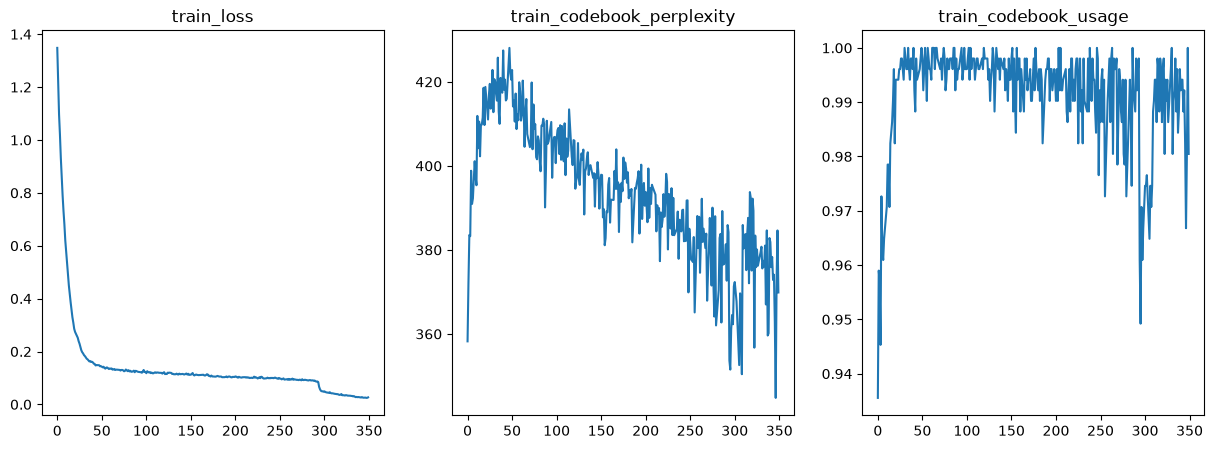

In [11]:
fig = plot_training_metrics(
    os.path.join(my_temp_dir, "stage1", "lightning_logs"),
    ["train_loss", "train_codebook_perplexity", "train_codebook_usage"],
)

### Reconstruction with uncertainty

`predict_step` returns `pred`, the mean over `num_samples` draws, and `pred_uct`, their standard deviation. This uncertainty comes from stochastic codebook sampling, so it is largest at positions where several codes are close to the encoder output and the draw can therefore land on different ones.

In [12]:
def plot_vqvae_reconstruction(batch: dict[str, Tensor], pred_dict: dict[str, Tensor]):
    """Plot VQ-VAE reconstruction results.

    Args:
        batch: input batch from the dataloader
        pred_dict: prediction dictionary from ``VQVAE.predict_step``
    """
    _fig, axs = plt.subplots(4, 3, figsize=(12, 16))
    for i in range(4):
        rand_idx = np.random.randint(0, batch["input"].shape[0])
        axs[i, 0].imshow(batch["input"][rand_idx, 0], cmap="gray")
        axs[i, 1].imshow(pred_dict["pred"][rand_idx, 0], cmap="gray")
        im = axs[i, 2].imshow(pred_dict["pred_uct"][rand_idx, 0], cmap="viridis")
        plt.colorbar(im, ax=axs[i, 2], fraction=0.046)
        for j in range(3):
            axs[i, j].axis("off")

    axs[0, 0].set_title("Input", fontsize=18)
    axs[0, 1].set_title("Reconstruction", fontsize=18)
    axs[0, 2].set_title("Uncertainty", fontsize=18)
    plt.tight_layout()
    plt.show()

mean predictive uncertainty: 0.08430


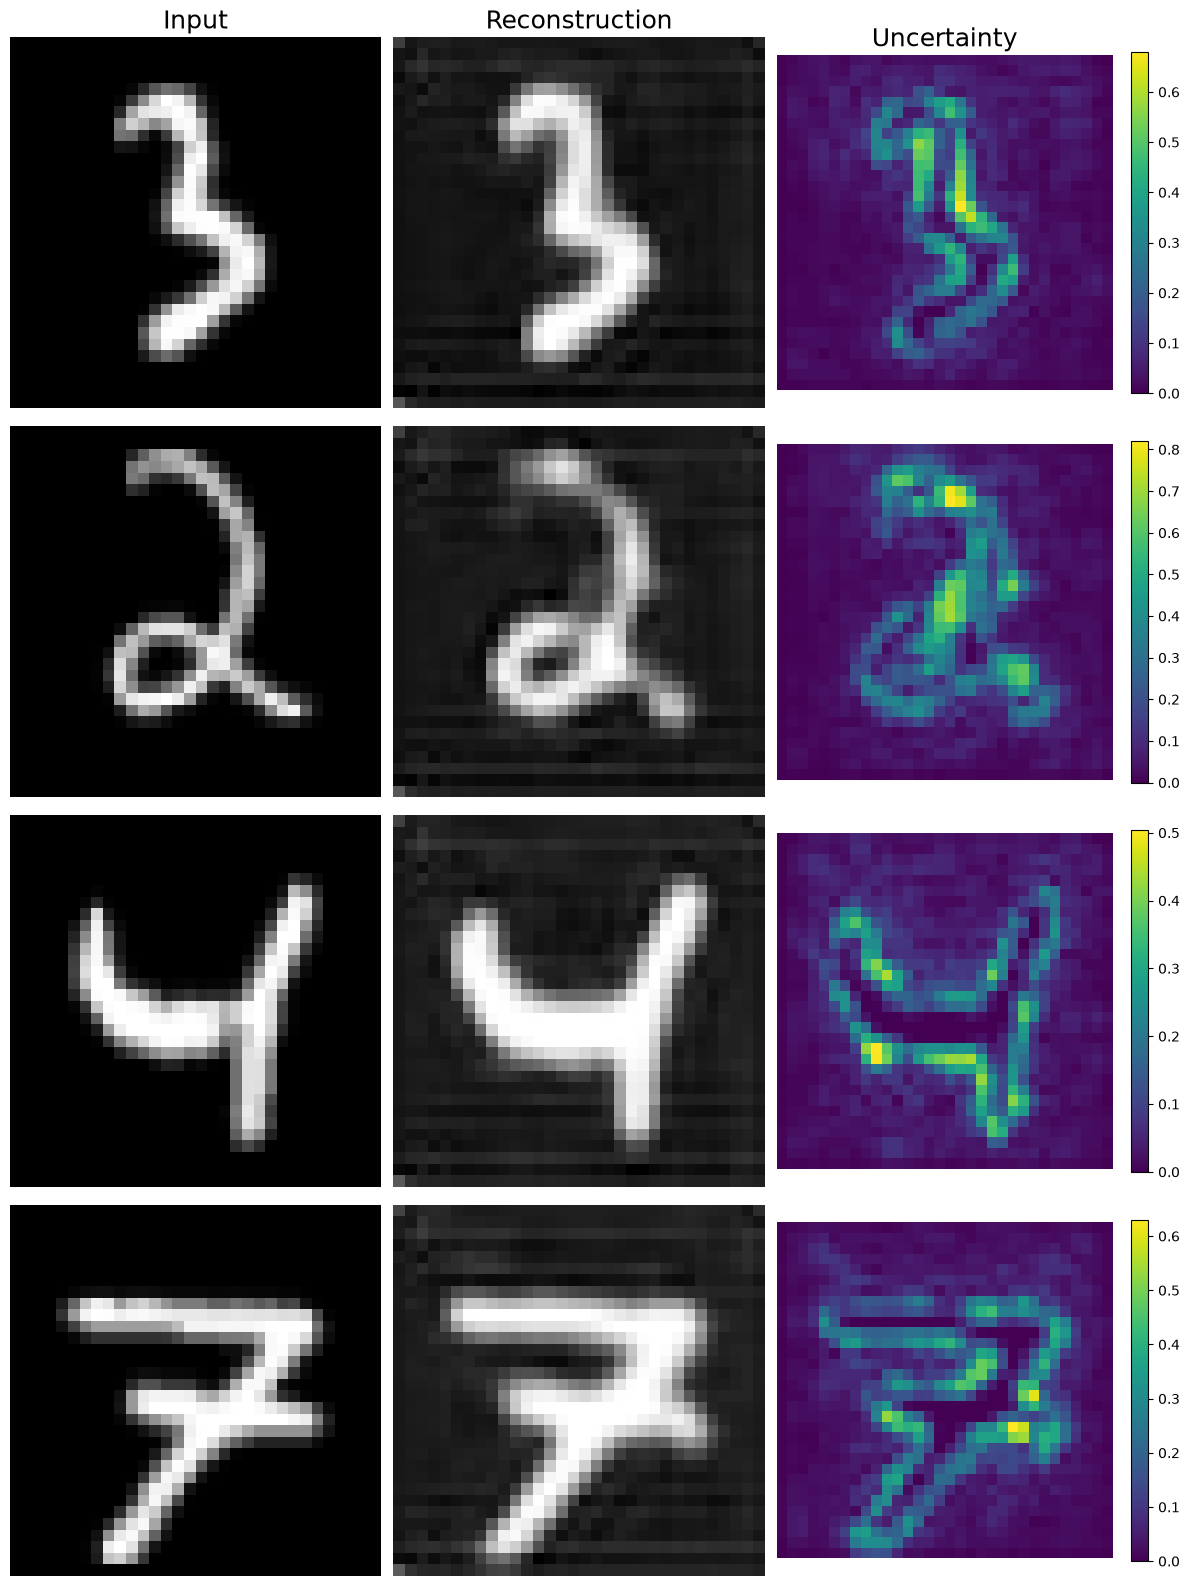

In [13]:
datamodule.setup("test")
with torch.no_grad():
    batch = next(iter(datamodule.test_dataloader()))
    pred_dict = vqvae.predict_step(batch["input"])

print(f"mean predictive uncertainty: {pred_dict['pred_uct'].mean():.5f}")
plot_vqvae_reconstruction(batch, pred_dict)

### Why we cannot generate yet

Calling `sample()` on a stage-1 VQ-VAE raises, since there is no distribution to draw indices from:

In [14]:
try:
    vqvae.sample(num_samples=4)
except NotImplementedError as e:
    print(f"NotImplementedError: {e}")

NotImplementedError: A VQ-VAE has no prior over its discrete latent, so it cannot sample unconditionally. Train a VQVAEPrior on this model and call sample() on that instead.


## Stage 2: a PixelCNN prior over the index grid

The missing distribution is what stage 2 supplies. We learn $p(\text{index grid})$ with a gated PixelCNN, which factorizes the joint distribution over the 8x8 grid autoregressively in raster-scan order:

$$p(z_{1:64}) = \prod_{i} p(z_i \mid z_{<i})$$

Here $z_i$ is the codebook index at grid position $i$ and $z_{<i}$ are the indices at all positions preceding it in raster-scan order, so each factor is a distribution over the 512 codes conditioned on the part of the grid already generated. Masked convolutions enforce this causality, using the vertical and horizontal stack design from [van den Oord et al. 2016](https://arxiv.org/abs/1606.05328) that avoids the blind spot of a naive mask.

`VQVAEPrior` takes the trained `VQVAE` and handles the associated bookkeeping:

- the VQ-VAE is frozen and set to eval, so stage 2 cannot change stage 1;
- only `pixel_cnn.parameters()` are passed to the optimizer;
- if you pass `vq_vae_ckpt_path`, the checkpoint is loaded strictly, so an architecture mismatch raises instead of training a prior against partially random weights.

Here we pass the model we just trained, so no checkpoint path is needed.

In [15]:
prior = VQVAEPrior(
    vq_vae=vqvae, c_hidden=64, optimizer=partial(torch.optim.Adam, lr=3e-4)
)

n_trainable = sum(p.numel() for p in prior.parameters() if p.requires_grad)
n_frozen = sum(p.numel() for p in prior.parameters() if not p.requires_grad)
print(f"trainable (PixelCNN): {n_trainable:,}")
print(f"frozen (VQ-VAE):      {n_frozen:,}")

trainable (PixelCNN): 949,952
frozen (VQ-VAE):      225,815


The training objective is cross-entropy over the `codebook_size` classes at each of the 64 grid positions. A prior that puts uniform mass over the 512 codes has a loss of $\ln(512) = 6.24$ nats and an accuracy of $1/512 \approx 0.2\%$, which are the reference points for reading the curves below.

In [16]:
print(f"untrained-prior reference loss: ln(512) = {np.log(512):.3f}")

logger_prior = CSVLogger(os.path.join(my_temp_dir, "stage2"))
trainer_prior = Trainer(
    max_epochs=15,
    accelerator="gpu",
    devices=[0],
    logger=logger_prior,
    enable_checkpointing=False,
    log_every_n_steps=20,
)
trainer_prior.fit(prior, datamodule)

untrained-prior reference loss: ln(512) = 6.238


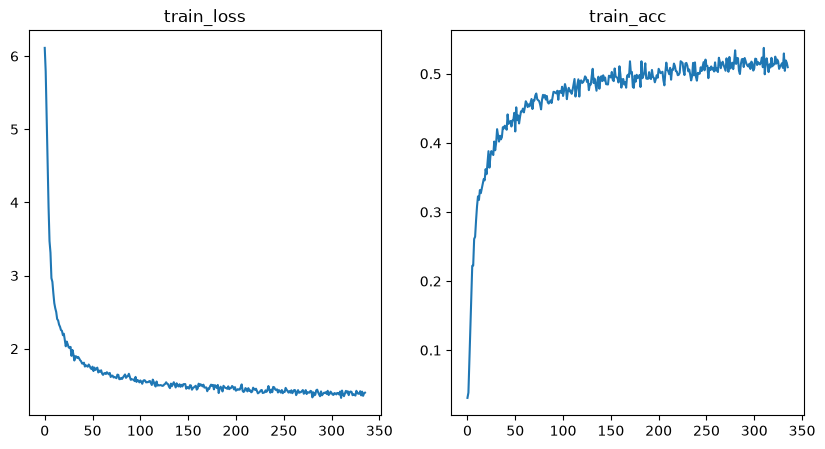

In [17]:
fig = plot_training_metrics(
    os.path.join(my_temp_dir, "stage2", "lightning_logs"), ["train_loss", "train_acc"]
)

### Generating samples by ancestral sampling

With the prior trained, we can draw a novel image. We sample the index grid one position at a time in raster-scan order: predict the distribution at position $i$ given everything sampled so far, draw from it, write the result back into the grid, and continue. Only once the full 8x8 grid exists do we look up the corresponding codebook vectors and run the decoder once.

Writing each index back before predicting the next is what conditions later positions on earlier ones, and therefore what makes a sample globally coherent rather than 64 independent draws. The cost is that grid positions cannot be parallelized, so an 8x8 grid takes 64 sequential forward passes per batch, though the batch dimension itself is still parallel.

`temperature` controls the sharpness of each draw. Below 1.0 the samples are more typical and less diverse, and above 1.0 the reverse.

samples: (16, 1, 32, 32)


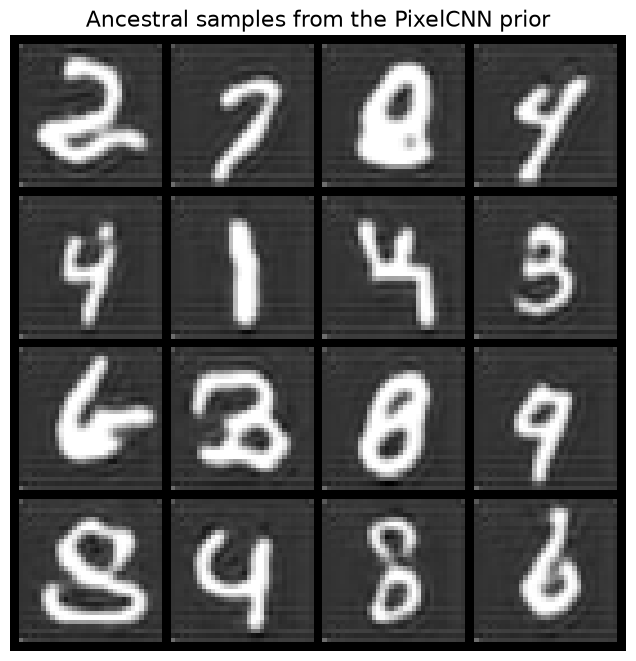

In [18]:
with torch.no_grad():
    samples = prior.sample(num_samples=16, temperature=1.0)

print(f"samples: {tuple(samples.shape)}")

grid = make_grid(samples.cpu(), nrow=4, normalize=True, padding=2)
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.set_title("Ancestral samples from the PixelCNN prior", fontsize=16)
ax.axis("off")
plt.show()

### The effect of temperature

Sweeping the temperature shows the trade-off between diversity and typicality directly.

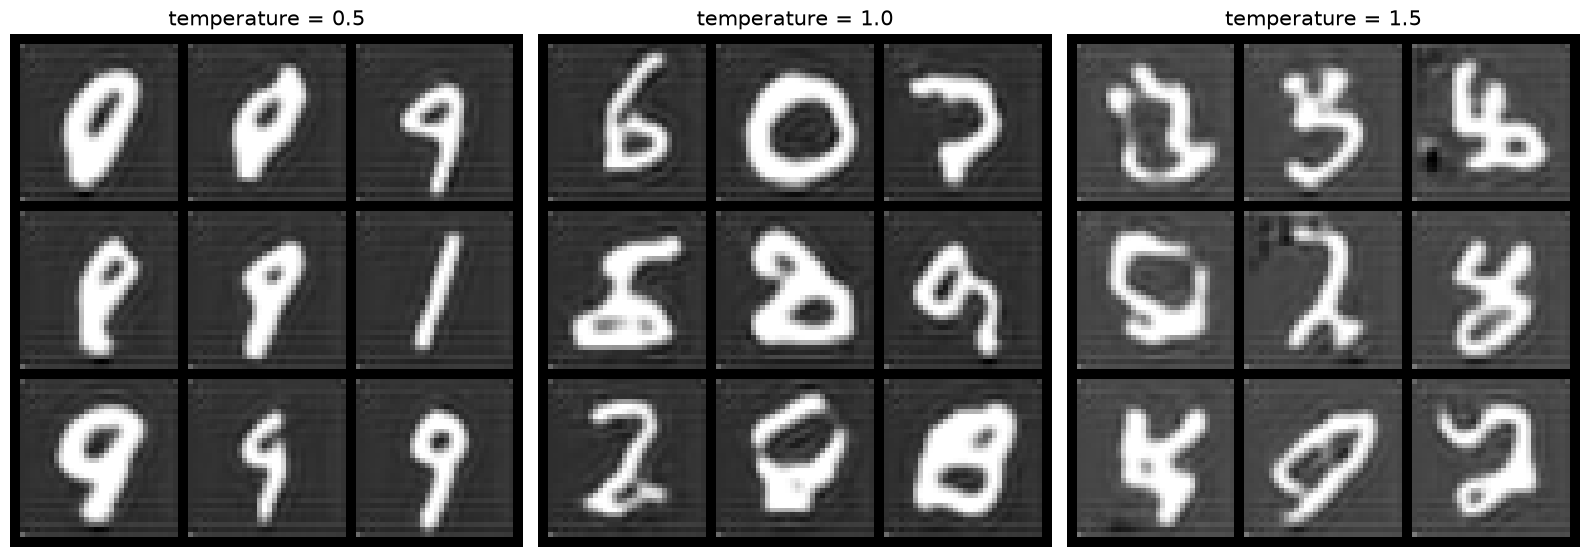

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))
for ax, temp in zip(axs, [0.5, 1.0, 1.5]):
    with torch.no_grad():
        s = prior.sample(num_samples=9, temperature=temp)
    grid = make_grid(s.cpu(), nrow=3, normalize=True, padding=2)
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(f"temperature = {temp}", fontsize=15)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Summary

- A VQ-VAE encodes an image to a grid of discrete codebook indices rather than a continuous Gaussian latent.
- A trained VQ-VAE can therefore reconstruct but cannot generate, since it has no prior over index grids.
- `predict_step` still returns an uncertainty, obtained from stochastic codebook sampling, which requires `sample_codebook_temp > 0` and `num_samples > 1`.
- Codebook perplexity and usage are worth monitoring alongside the loss, since a low reconstruction loss with a collapsed codebook indicates a failed model. The anti-collapse defaults are `decay=0.99`, `kmeans_init=True` and `threshold_ema_dead_code=2`.
- Two settings are invisible to a forward-pass test: `stochastic_sample_codes` leaking into training, and `rotation_trick` replacing the paper's straight-through estimator. The defaults here handle both, which is worth knowing if you build a quantizer yourself.
- Generation comes from the second stage, where `VQVAEPrior` trains a PixelCNN over the index grid and `sample()` draws from it ancestrally, one grid position at a time.

The same two-stage recipe applies to larger images by increasing the encoder depth or the input size. Sampling cost grows with the square of the grid side, so a 16x16 grid requires four times the sequential work of an 8x8 one.